In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, auc, f1_score, matthews_corrcoef
from sklearn.model_selection import train_test_split

from rapidgbm import RapidGBMTuner

import glob
import mplhep as hep
hep.style.use([hep.style.ATLAS])
import pickle

import uproot
from iminuit import Minuit

In [22]:
iso_param_list = ['m_lx_ptcone20', 'm_lx_ptcone20_pt1000', 'm_lx_ptcone20_pt500', 'm_lx_ptcone30',
                  'm_lx_ptvarcone20', 'm_lx_ptvarcone30', 'm_lx_ptvarcone30_pt1000', 'm_lx_ptvarcone30_pt500',
                  'm_lx_topoetcone20', 'm_lx_topoetcone20ptCorrection', 'm_lx_topoetcone40', 'm_lx_neflowisol20']

iso_1_param_list = ['l1_ptcone20', 'l1_ptcone20_pt1000', 'l1_ptcone20_pt500', 'l1_ptcone30',
                    'l1_ptvarcone20', 'l1_ptvarcone30', 'l1_ptvarcone30_pt1000', 'l1_ptvarcone30_pt500',
                    'l1_topoetcone20', 'l1_topoetcone20ptCorrection', 'l1_topoetcone40', 'l1_neflowisol20']

iso_2_param_list = ['l2_ptcone20', 'l2_ptcone20_pt1000', 'l2_ptcone20_pt500', 'l2_ptcone30',
                    'l2_ptvarcone20', 'l2_ptvarcone30', 'l2_ptvarcone30_pt1000', 'l2_ptvarcone30_pt500',
                    'l2_topoetcone20', 'l2_topoetcone20ptCorrection', 'l2_topoetcone40', 'l2_neflowisol20']

pred_z_param_list = ['l1_iso_score', 'l2_iso_score', 
                     'l1_DNN_pel', 'l1_z0', 'l1_sig_z0', 'l2_DNN_pel', 'l2_z0', 'l2_sig_z0', 'EventInfo.actualIntPerXing',
                     'EventInfo.averageIntPerXing', 'EventInfo.mu', 'l1_DNN_pcf', 'l1_DNN_phf', 'l1_DNN_ple', 'l1_DNN_plh', 
                     'l1_DNN_ppc', 'l1_ECID', 'l1_charge', 'l2_DNN_pcf', 'l2_DNN_phf', 'l2_DNN_ple', 'l2_DNN_plh', 'l2_DNN_ppc',
                     'l2_ECID', 'l2_charge',]

others = ['EventInfo.eventNumber', 'truth_from_Z', 'EventInfo.cutflow', 'EventInfo.cutflow_new', 
          'll_m', 'l1_truthType', 'l2_truthType', 'llg_m', 'EventInfo.channel', 'l1_truthOrigin', 'l2_truthOrigin'
        ]

others_data = ['EventInfo.eventNumber', 'EventInfo.cutflow', 'EventInfo.cutflow_new', 
          'll_m', 'llg_m', 'EventInfo.channel'
        ]

small_iso_param_list1 = iso_1_param_list[-4:]
small_iso_param_list2 = iso_2_param_list[-4:]

param_list = iso_1_param_list + iso_2_param_list + pred_z_param_list[2:] + others

In [23]:
data_mc = pd.read_parquet('/groups/hep/kinch/data/preprocessed_data/files_from_grid/Data_BalZ_ttbar_zee_ttbardoubleisofiltered.parquet')

data_true_22 = pd.read_parquet('/groups/hep/kinch/data/Data/data22_13p6TeV.periodAllYear.physics_Main.PhysCont.DAOD_PHYS.grp22_v01_p6029/hist-sample_reduced.parquet')
print(f'shape data 22: {data_true_22.shape}')
data_true_23 = pd.read_parquet('/groups/hep/kinch/data/Data/data23_13p6TeV.periodAllYear.physics_Main.PhysCont.DAOD_PHYS.grp23_v01_p6029/hist-sample_reduced.parquet')
print(f'shape data 23: {data_true_23.shape}')
print(f'shape MC data: {data_mc.shape}')

# true_data = pd.concat([true_data_22, true_data_23])
data_true = pd.concat([data_true_22, data_true_23])
print(data_true['EventInfo.channel'].value_counts())
# print(MC_data['EventInfo.channel'].value_counts())
print(data_true.shape)
true_data = data_true[true_data['EventInfo.channel'] == 1]
print(f'shape true data: {true_data.shape}')

shape data 22: (32936, 53)
shape data 23: (45757, 53)
shape MC data: (8396728, 60)
EventInfo.channel
1    78693
Name: count, dtype: int64
(78693, 53)
shape true data: (78693, 53)


In [24]:
delta_z0 = np.zeros(data_true.shape[0])
delta_sig_z0 = np.zeros(data_true.shape[0])

delta_z0 = np.abs(data_true['l1_z0'] - data_true['l2_z0'])
delta_sig_z0 = np.sqrt(data_true['l1_sig_z0']**2 + data_true['l2_sig_z0']**2)

delta_z0_norm = delta_z0/delta_sig_z0

data_true['DZ0'] = delta_z0_norm

delta_z0_MC = np.zeros(data_mc.shape[0])
delta_sig_z0_MC = np.zeros(data_mc.shape[0])

delta_z0_MC = np.abs(data_mc['l1_z0'] - data_mc['l2_z0'])
delta_sig_z0_MC = np.sqrt(data_mc['l1_sig_z0']**2 + data_mc['l2_sig_z0']**2)

delta_z0_norm_MC = delta_z0_MC/delta_sig_z0_MC

data_mc['DZ0'] = delta_z0_norm_MC

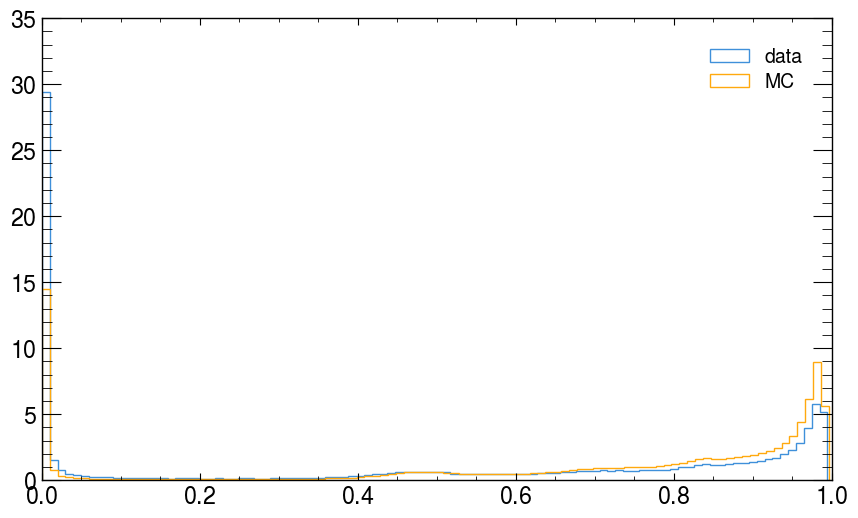

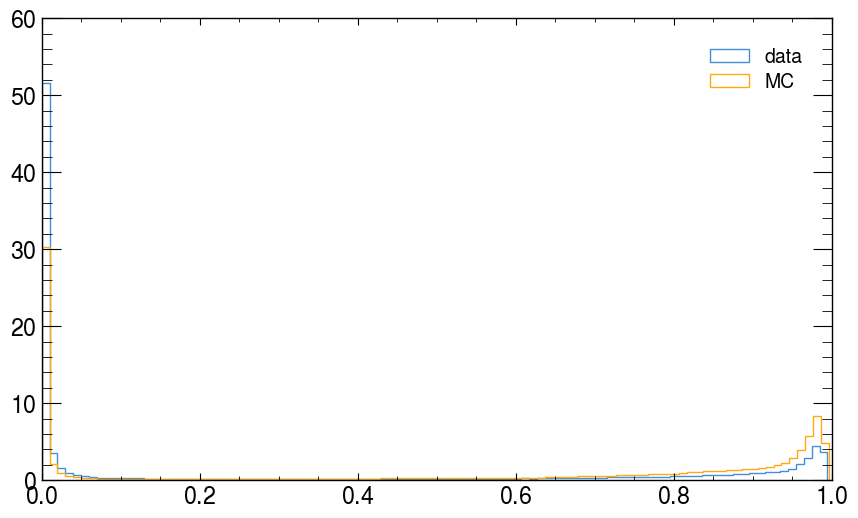

In [25]:
# iso predictions (small iso model)

iso1_mc = np.zeros(data_mc.shape[0])
iso2_mc = np.zeros(data_mc.shape[0])

iso1_data = np.zeros((data_true.shape[0],4))
iso2_data = np.zeros((data_true.shape[0],4))


X_test1_data = data_true[small_iso_param_list1]
X_test2_data = data_true[small_iso_param_list2]
for i in range(4):
    mask = data_mc['EventInfo.eventNumber']%4 == i

    X_test1_mc = data_mc[small_iso_param_list1][mask]
    X_test2_mc = data_mc[small_iso_param_list2][mask]

    with open(f'small_param_iso_tuner_{i}.pkl' , 'rb') as f:
        tuner = pickle.load(f)
    
    iso1_mc[mask] = tuner.predict_proba(X_test1_mc)
    iso2_mc[mask] = tuner.predict_proba(X_test2_mc)

    iso1_data[:,i] = tuner.predict_proba(X_test1_data)
    iso2_data[:,i] = tuner.predict_proba(X_test2_data)

iso1_data = np.mean(iso1_data, axis=1)
iso2_data = np.mean(iso2_data, axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(iso1_data, bins=100, histtype='step', label='data', density=True)
ax.hist(iso1_mc, bins=100, histtype='step', label='MC', density=True)
ax.legend()
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(iso2_data, bins=100, histtype='step', label='data', density=True)
ax.hist(iso2_mc, bins=100, histtype='step', label='MC', density=True)
ax.legend()

data_true['l1_iso_score'] = iso1_data
data_true['l2_iso_score'] = iso2_data

data_mc['l1_iso_score'] = iso1_mc
data_mc['l2_iso_score'] = iso2_mc

In [29]:
opposite_sign = data_mc['l1_charge'] != data_mc['l2_charge']
print(f'opposite sign: {opposite_sign.sum()}, same sign: {len(opposite_sign) - opposite_sign.sum()}')

opposite_sign = data_true['l1_charge'] != data_true['l2_charge']
print(f'opposite sign: {opposite_sign.sum()}, same sign: {len(opposite_sign) - opposite_sign.sum()}')

opposite_sign_truth = data_mc['l1_truthPdgId']*data_mc['l2_truthPdgId'] < 0
print(f'opposite sign (truth): {opposite_sign_truth.sum()}, same sign: {len(opposite_sign_truth) - opposite_sign_truth.sum()}')

print(data_mc['l1_ECID'].value_counts())

opposite sign: 8396728, same sign: 0
opposite sign: 78693, same sign: 0
opposite sign (truth): 6217302, same sign: 2179426
l1_ECID
1.0    7464806
0.0     931922
Name: count, dtype: int64
